# Meta-Llama-3-8B × opc-sft-stage2 leaderboard — long-horizon (r=256, 9000 steps)

Scale-up cell of the polar-product campaign. Meta-Llama-3-8B (base) × `opc-sft-stage2` (Magicoder) × r=256 × **global_batch=16 (batch=2 × accum=8 — 8B needs bs2 for 96GB-Blackwell headroom)** × packed_v1.1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell.

Data reuses the `_llama32` packed corpus (Llama-3/3.1/3.2 share an identical token id-mapping). Speed metric = fraction of the 9000-step horizon a method needs to reach the best AdamW final eval_loss (lower = better). Runs in flight render partially (`allow_partial=True`); the panel shows a placeholder until the first eval (step 250).

**Launched arms (exactly what is running):**
- **AdamW** baseline / speed-target — `adamw_llama3_8b_opc_r256`, lrs `1e-5, 3e-5, 1e-4, 3e-4`
- **chord-tight-clean k=1 ns=8** — `chord_tight_clean_k1_8b_opc_r256`, lrs `3e-3, 1e-2, 3e-2, 1e-1`
- **chord-tight-clean k=2 ns=8** — `chord_tight_clean_8b_opc_r256`, lrs `3e-3, 1e-2, 3e-2, 1e-1`

k=1 and k=2 are both clean (Alg 2′ §2.5 pre-rescale); the only difference is the Picard cross-term (k≥2 only), so this cell directly tests whether the extra Picard iteration earns its cost at 8B.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Repo root by marker-walk, so this notebook works from any subdir.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import leaderboard_panel

MODEL, DATASET, RANK = 'meta-llama/Meta-Llama-3-8B', 'opc', 256

## r=256 — AdamW vs chord-tight-clean k=1 & k=2 (all launched arms)

Every in-flight + completed run at this cell. Each lr renders from its first eval (step ~250). The summary table (`sdf`) gives final loss, best-lr, speed-to-AdamW-target, and Δ/σ. Renders a 'no evals yet' placeholder if run before the first eval.

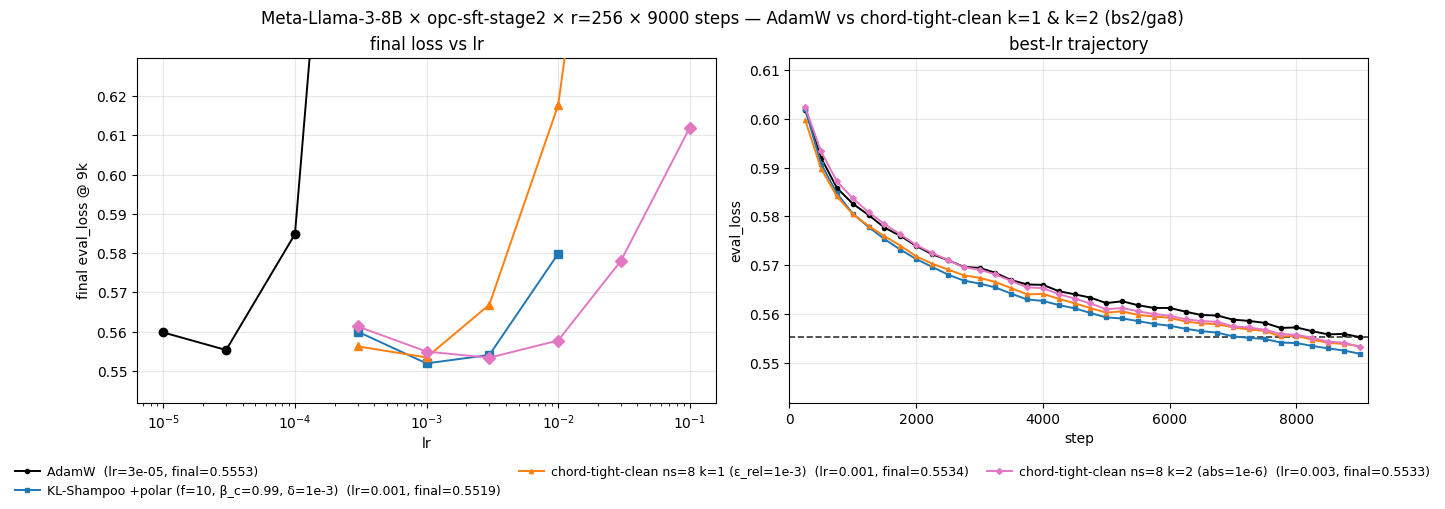

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,NaN,NaN
1,"KL-Shampoo +polar (f=10, β_c=0.99, δ=1e-3)",0.00100,0.551901,-0.003402,-2.001318
2,chord-tight-clean ns=8 k=1 (ε_rel=1e-3),0.00100,0.553417,-0.001886,-1.109388
3,chord-tight-clean ns=8 k=2 (abs=1e-6),0.00300,0.553345,-0.001959,-1.152224


In [2]:
_fig, _tdf, sdf = leaderboard_panel(MODEL, DATASET, RANK,
    'Meta-Llama-3-8B × opc-sft-stage2 × r=256 × 9000 steps — AdamW vs chord-tight-clean k=1 & k=2 (bs2/ga8)',
    figsize=(13, 5))
plt.show()
sdf